In [1]:
import numpy as np
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

BSR dataset in LXCat is computed via quantum-mechanics simulations, which we include in first Bayesian inference.

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.60e+01 4.19e-18 2.90e+01]
 [2.00e+01 3.19e-18 2.90e+01]
 [3.00e+01 1.66e-18 2.90e+01]
 [5.00e+01 3.61e-19 3.30e+01]
 [1.00e+02 5.60e-20 4.70e+01]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.60e+01 3.97e-18 2.90e+01]
 [2.00e+01 3.70e-18 2.90e+01]
 [3.00e+01 4.56e-18 2.90e+01]
 [5.00e+01 5.78e-18 2.90e+01]
 [1.00e+02 3.28e-18 2.90e+01]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.60e+01 6.09e-19 3.30e+01]
 [2.00e+01 6.44e-19 3.30e+01]
 [3.00e+01 4.54e-19 4.70e+01]
 [5.00e+01 1.12e-19 4.70e+01]
 [1.00e+02 5.41e-20 4.70e+01]]
Excitation, level 4
['E', 'crs', 'crs-rms']
[[1.60e+01 8.53e-18 2.90e+01]
 [2.00e+01 1.00e-17 2.90e+01]


11.549
[[1.155110e+01 1.713810e-23 8.569050e-24]
 [1.156470e+01 4.743930e-23 2.371965e-23]
 [1.157830e+01 6.904390e-23 3.452195e-23]
 ...
 [2.500010e+02 2.228150e-25 1.114075e-25]
 [2.750010e+02 1.594720e-25 7.973600e-26]
 [3.000010e+02 1.187040e-25 5.935200e-26]]


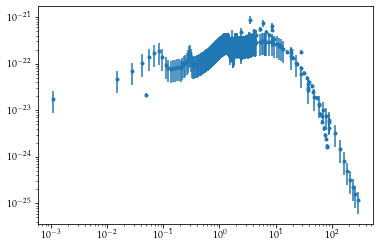

In [4]:
dataType = crs.typeDictS2I['Excitation, level 1']

# W = [[]]
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
                
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/excitation-level1/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE<11.6)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
        print(temp)
    
E1 = 11.55
plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

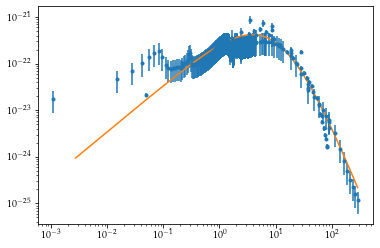

In [5]:
from models import *
theta_ref = [51.2, 2]

model0 = Excite_metastable(1,theta_ref,np.sort(W[:,0]))

plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[0],model0,'-')
plt.xscale('log')
plt.yscale('log')

Log-prior of level-1 excitation

2.8424051697695505e-22


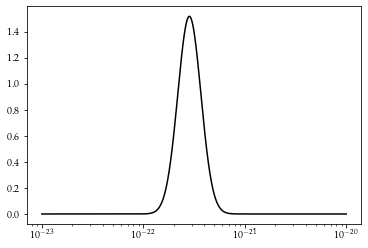

In [6]:
def log_prior_ext1(theta):
    theta_ref = np.array([51.2, 2])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext1(theta, E, y, yerr):
    # compute log-normal probability
    n = 1
    logModel = np.log( Excite_metastable(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext1(theta, E, y, yerr):
    lp = log_prior_ext1(theta)
    lk = log_likelihood_ext1(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

E_test = E_ext[0] + 10.0
y0 = Excite_metastable(1,theta_ref,E_test)
print(y0)

N = 1000
y_test = np.linspace(-23,-20,N)
y_test = 10.0**y_test
loglikely = np.zeros(N,)
for k in range(N):
    loglikely[k] = log_likelihood_ext1(theta_ref,E_test,y_test[k],y_test[k]*0.3)

plt.figure(1)
plt.semilogx(y_test,np.exp(loglikely),'-k')

In [7]:
import emcee
nwalkers = 32
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext1, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 988.39it/s]


In [8]:
tau = sampler.get_autocorr_time()
print(tau)

[37.62005486 37.88612955]


In [9]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 2)


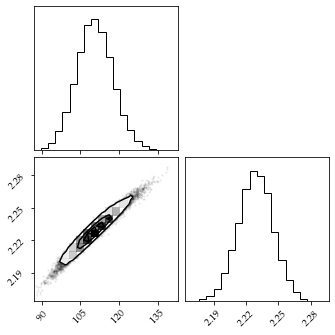

In [10]:
import corner

fig = corner.corner(flat_samples);

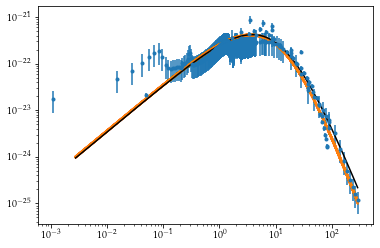

In [11]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[0], Excite_metastable(1,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[0],model0,'-k')
plt.xscale('log')
plt.yscale('log')

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

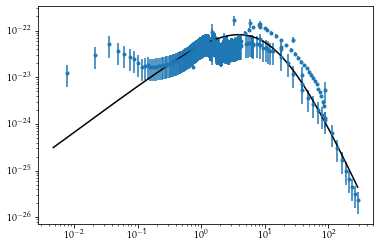

In [12]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 3']

# del W
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level3/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.7) and (c.deltaE<11.8)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
    
E3 = 11.72
theta_ref = np.array([10.4, 2])
model0 = Excite_metastable(3,theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E3,W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ext[2],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [13]:
def log_prior_ext3(theta):
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([10.4, 2])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext3(theta, E, y, yerr):
    # compute log-normal probability
    n = 3
    logModel = np.log( Excite_metastable(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext3(theta, E, y, yerr):
    lp = log_prior_ext3(theta)
    lk = log_likelihood_ext3(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [14]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4, 2])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext3, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_22563/2402511244.py:11: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(n,theta,E) )
100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 991.90it/s]


In [15]:
tau = sampler.get_autocorr_time()
print(tau)

[50.40560646 66.15434149]


In [16]:
flat_samples = sampler.get_chain(discard=150, thin=30, flat=True)
print(flat_samples.shape)

(5152, 2)


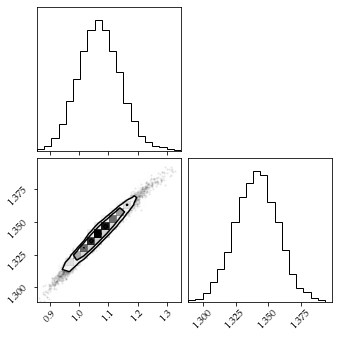

In [17]:
import corner

fig = corner.corner(flat_samples);

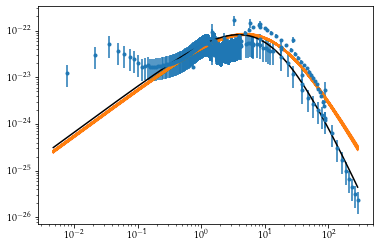

In [18]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[2], Excite_metastable(3,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E3,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[2],model0,'-k')
plt.xscale('log')
plt.yscale('log')

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross se

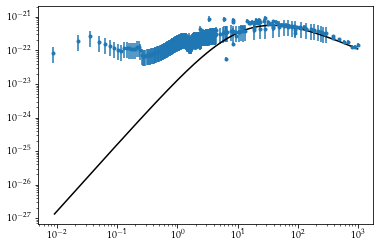

In [19]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 2']

# del W
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level3/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.6) and (c.deltaE<11.7)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
    
E2 = 11.624
theta_ref = np.array([0.61e0,1.0])
model0 = Excite_resonance(2,theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E2,W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ext[1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [20]:
def log_prior_ext2(theta):
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([0.61e0,1.0])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext2(theta, E, y, yerr):
    # compute log-normal probability
    n = 2
    logModel = np.log( Excite_resonance(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext2(theta, E, y, yerr):
    lp = log_prior_ext2(theta)
    lk = log_likelihood_ext2(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [21]:
import emcee
nwalkers = 32
theta_ref = np.array([0.61e0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext2, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_22563/842195602.py:11: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(n,theta,E) )
100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 780.56it/s]


In [22]:
tau = sampler.get_autocorr_time()
print(tau)

[30.01519278 28.59459039]


In [23]:
flat_samples = sampler.get_chain(discard=80, thin=15, flat=True)
print(flat_samples.shape)

(10496, 2)


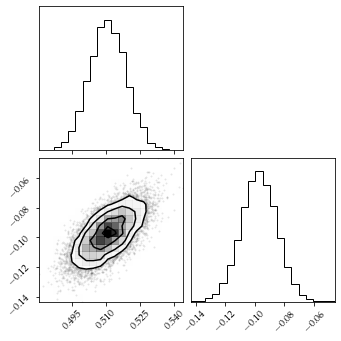

In [24]:
import corner

fig = corner.corner(flat_samples);

(1e-24, 3e-21)

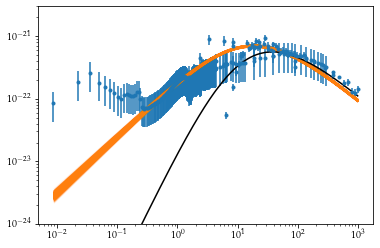

In [25]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[1], Excite_resonance(2,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E2,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[1],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-24, 3e-21])

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
15.071227991895011
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination o

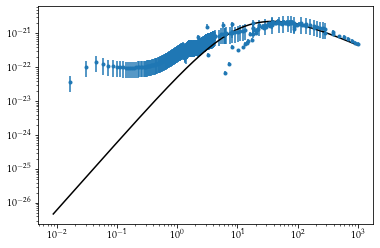

In [26]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 4']

# del W
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level3/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
    
E4 = 11.82
theta_ref = np.array([2.54e0,1.0])
model0 = Excite_resonance(4,theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E4,W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [27]:
def log_prior_ext4(theta):
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([2.54e0,1.0])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext4(theta, E, y, yerr):
    # compute log-normal probability
    n = 4
    logModel = np.log( Excite_resonance(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext4(theta, E, y, yerr):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [28]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_22563/3813543812.py:11: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(n,theta,E) )
100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 785.46it/s]


In [29]:
tau = sampler.get_autocorr_time()
print(tau)

[32.01722465 32.41585431]


In [30]:
flat_samples = sampler.get_chain(discard=80, thin=15, flat=True)
print(flat_samples.shape)

(10496, 2)


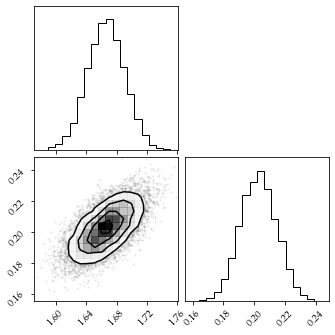

In [31]:
import corner

fig = corner.corner(flat_samples);

(1e-24, 3e-21)

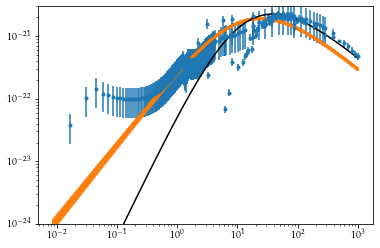

In [32]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[3], Excite_resonance(4,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E4,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-24, 3e-21])